# Main study: pooled over-2.5 edge analysis

## Unified all-league model, two-season rolling window, L2 = 100

**Research question.** After selecting the most stable ridge setting in notebook 02, does a single model trained across all leagues produce useful out-of-sample forecasts or an executable betting edge?

This is the presentation analysis for the selected specification. Notebook 02 remains the regularization sensitivity study and should be read alongside this notebook: choosing L2 = 100 after comparing configurations means the results below are not an untouched confirmatory test.

In [13]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from football_edge.backtest import (
    build_execution_candidates,
    build_research_dataset,
    monthly_roi,
    probability_performance,
    run_pooled_rolling_walk_forward,
    summarize_bets,
)
from football_edge.config import MINIMUM_EXPECTED_VALUE, RAW_DATA_DIR
from football_edge.data import discover_datasets
from football_edge.plotting import (
    SOURCE_COLORS,
    SOURCE_LABELS,
    plot_monthly_metric,
    plot_overall_roi_by_execution,
)

SELECTED_L2 = 100.0
TRAINING_WINDOW = 2
MODEL_NAME = "Pooled L2 = 100"

pd.options.display.float_format = "{:,.3f}".format
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Research design

For each test season, one logistic-regression model is fitted to every available match from all four leagues in exactly the preceding two seasons. League indicators permit different baseline levels, while the market and form slopes are shared.

The five continuous predictors are the no-vig pre-closing market log-odds, home and away season-to-date scoring averages, and home and away trailing-five scoring averages. Team-history variables are shifted so the current match cannot enter its own features.

L2 = 100 was selected because notebook 02 found it to be the best calibrated fitted configuration. It did not beat the raw market on proper scoring rules, so this notebook treats economic results as exploratory rather than independent confirmation.

In [14]:
datasets = discover_datasets(RAW_DATA_DIR)
all_matches = build_research_dataset(datasets)
predictions, fold_coefficients = run_pooled_rolling_walk_forward(
    all_matches,
    l2=SELECTED_L2,
    model_name=MODEL_NAME,
    training_window=TRAINING_WINDOW,
)

sample_design = (
    predictions.groupby("season")
    .agg(
        test_matches=("date", "size"),
        leagues=("league", "nunique"),
        training_seasons=("training_seasons", "first"),
        training_matches=("training_matches", "first"),
        train_end=("train_end_date", "first"),
        test_start=("test_start_date", "first"),
    )
)
assert (sample_design["train_end"] < sample_design["test_start"]).all()
sample_design

,test_matches,leagues,training_seasons,training_matches,train_end,test_start
season,,,,,,
23_24,1407,4,"21_22,22_23",2813,2023-06-04 20:00:00,2023-08-18 18:30:00
24_25,1407,4,"22_23,23_24",2814,2024-06-02 17:00:00,2024-08-23 18:00:00
25_26,1407,4,"23_24,24_25",2814,2025-05-25 20:00:00,2025-08-22 20:00:00


## 2. Out-of-sample probability performance

Brier score and log loss are proper probability-scoring rules; lower values are better. Calibration intercept and slope should be near 0 and 1. The raw no-vig market is the relevant benchmark because the model already uses market probability as a feature.

In [15]:
model_metrics = probability_performance(
    predictions.assign(forecaster="Pooled model"),
    probability_column="model_probability",
    group_by=["forecaster"],
)
market_metrics = probability_performance(
    predictions.assign(forecaster="Raw no-vig market"),
    probability_column="market_over_probability",
    group_by=["forecaster"],
)
overall_probability_metrics = pd.concat(
    [model_metrics, market_metrics], ignore_index=True
).set_index("forecaster")
overall_probability_metrics.round(4)

,observations,brier_score,log_loss,accuracy,calibration_intercept,calibration_slope,mean_probability,event_rate
forecaster,,,,,,,,
Pooled model,4221,0.237,0.668,0.592,0.036,1.002,0.530,0.539
Raw no-vig market,4221,0.237,0.667,0.593,0.024,1.105,0.531,0.539


In [16]:
model_by_season = probability_performance(
    predictions,
    probability_column="model_probability",
    group_by=["season"],
).assign(forecaster="Pooled model")
market_by_season = probability_performance(
    predictions,
    probability_column="market_over_probability",
    group_by=["season"],
).assign(forecaster="Raw no-vig market")
probability_by_season = pd.concat(
    [model_by_season, market_by_season], ignore_index=True
)
probability_by_season.pivot(
    index="season", columns="forecaster", values=["brier_score", "log_loss"]
).round(4)

brier_score                       log_loss                  
forecaster Pooled model Raw no-vig market Pooled model Raw no-vig market
season                                                                  
23_24             0.233             0.232        0.657             0.657
24_25             0.238             0.237        0.668             0.667
25_26             0.242             0.242        0.677             0.677

In [17]:
model_by_league = probability_performance(
    predictions,
    probability_column="model_probability",
    group_by=["league"],
).assign(forecaster="Pooled model")
market_by_league = probability_performance(
    predictions,
    probability_column="market_over_probability",
    group_by=["league"],
).assign(forecaster="Raw no-vig market")
probability_by_league = pd.concat(
    [model_by_league, market_by_league], ignore_index=True
)
probability_by_league.pivot(
    index="league", columns="forecaster", values=["brier_score", "log_loss"]
).round(4)

brier_score                       log_loss                  
forecaster     Pooled model Raw no-vig market Pooled model Raw no-vig market
league                                                                      
Bundesliga            0.225             0.226        0.641             0.643
La Liga               0.236             0.236        0.665             0.665
Premier League        0.239             0.238        0.671             0.669
Serie A               0.247             0.247        0.688             0.686

**Interpretation.** The selected model should be judged against the market both overall and within each season and league. A small aggregate improvement that is concentrated in one subgroup would not constitute robust evidence.

## 3. Coefficient stability

The coefficients are fitted on standardized predictors within each rolling training window. The chart shows whether the shared market and form slopes retain similar signs and magnitudes across the three out-of-sample folds. League indicators are omitted for readability.

In [18]:
shared_features = [
    "market_logit",
    "home_season_avg_goals",
    "away_season_avg_goals",
    "home_last_5_avg_goals",
    "away_last_5_avg_goals",
]
coefficient_table = (
    fold_coefficients.loc[fold_coefficients["coefficient"].isin(shared_features)]
    .pivot(index="coefficient", columns="test_season", values="value")
    .reindex(shared_features)
)
coefficient_table.round(3)

test_season,23_24,24_25,25_26
coefficient,,,
market_logit,0.347,0.381,0.378
home_season_avg_goals,-0.008,0.054,0.079
away_season_avg_goals,-0.005,0.036,0.092
home_last_5_avg_goals,-0.001,-0.051,-0.048
away_last_5_avg_goals,-0.002,0.010,-0.032


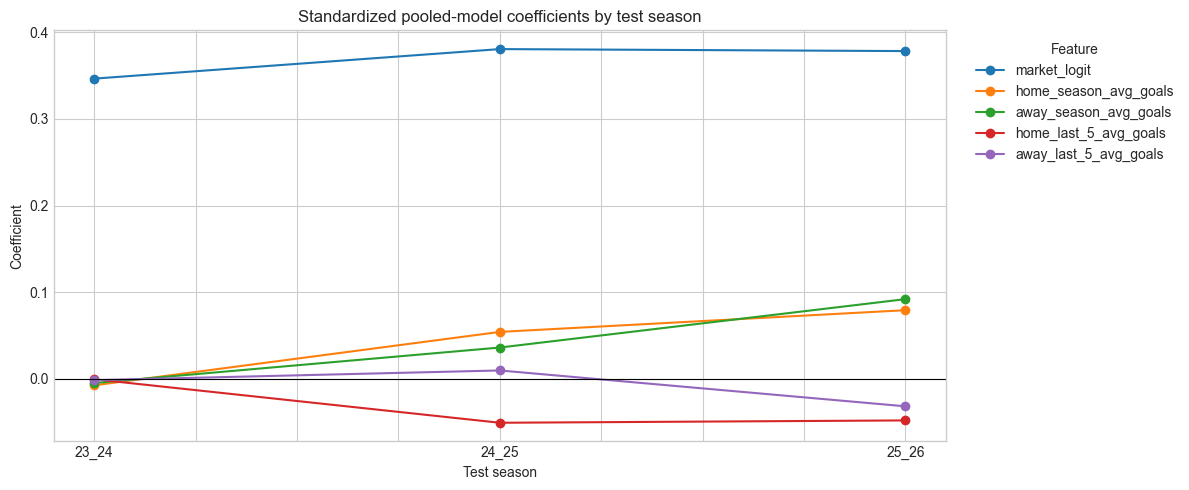

In [19]:
ax = coefficient_table.T.plot(marker="o", figsize=(12, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    title="Standardized pooled-model coefficients by test season",
    xlabel="Test season",
    ylabel="Coefficient",
)
ax.legend(title="Feature", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

## 4. Execution-price betting backtest

For each execution scenario, a flat one-unit over-2.5 bet is selected when estimated expected value is at least 3%:

$$\hat p_{model} \times \text{decimal odds} - 1 \geq 0.03.$$

The same model probability is used for Bet365, Pinnacle, Betfair Exchange, the market average, and the pre-closing market maximum. `MaxC>2.5` is added as a separate **closing market maximum** sensitivity. It represents the best closing quote observed across the covered market, not a guaranteed executable bookmaker price. Its CLV is undefined because the dataset contains no later benchmark. Betfair returns are gross because commission is configured as zero.

,execution_source,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,average_preclosing,17,9,52.941,1.864,-0.400,-2.353,-48.532,43.826,-0.460,4.210
1,best_closing,1045,516,49.378,2.128,16.580,1.587,-4.924,8.097,NaN,30.720
2,best_preclosing,201,110,54.726,1.876,0.350,0.174,-12.773,13.121,-1.063,14.960
3,bet365,63,30,47.619,1.938,-5.170,-8.206,-32.841,16.428,-0.005,9.300
4,betfair_exchange,355,188,52.958,1.936,0.840,0.237,-9.945,10.418,-0.967,15.750
5,pinnacle,101,49,48.515,1.912,-11.490,-11.376,-29.713,6.961,-1.163,14.850


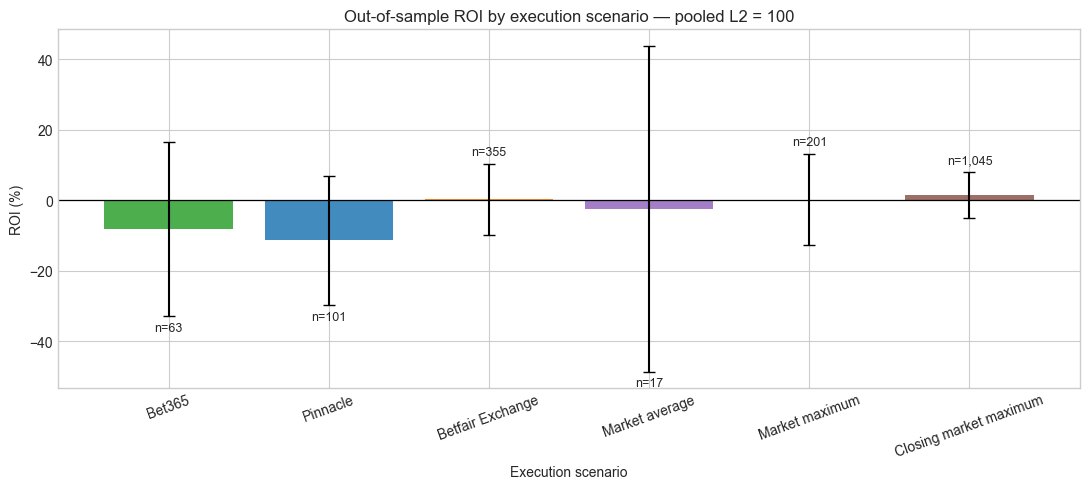

In [20]:
execution_candidates = build_execution_candidates(
    predictions, include_closing_prices=True
)
execution_bets = execution_candidates.loc[
    execution_candidates["expected_value"] >= MINIMUM_EXPECTED_VALUE
].copy()

overall_performance = summarize_bets(
    execution_bets, ["execution_source"]
).sort_values("execution_source")
display(overall_performance.round(3))
plot_overall_roi_by_execution(
    overall_performance,
    title="Out-of-sample ROI by execution scenario — pooled L2 = 100",
)
plt.show()

In [21]:
performance_by_season = summarize_bets(
    execution_bets, ["execution_source", "season"]
)
performance_by_league = summarize_bets(
    execution_bets, ["execution_source", "league"]
)
display(performance_by_season.round(3))
performance_by_league.round(3)

,execution_source,season,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,average_preclosing,24_25,6,4,66.667,1.857,1.650,27.500,-52.224,107.224,-0.151,1.000
1,average_preclosing,25_26,11,5,45.455,1.868,-2.050,-18.636,-75.655,38.382,-0.628,4.210
2,best_closing,23_24,339,165,48.673,2.186,12.380,3.652,-8.068,15.372,NaN,16.620
3,best_closing,24_25,423,211,49.882,2.057,-7.530,-1.780,-11.637,8.077,NaN,30.720
4,best_closing,25_26,283,140,49.470,2.166,11.730,4.145,-8.684,16.974,NaN,10.300
5,best_preclosing,23_24,2,1,50.000,2.275,0.200,10.000,-205.600,225.600,-1.219,1.000
6,best_preclosing,24_25,129,72,55.814,1.806,-1.680,-1.302,-16.701,14.096,-1.740,11.960
7,best_preclosing,25_26,70,37,52.857,1.993,1.830,2.614,-21.145,26.374,0.189,8.840
8,bet365,24_25,21,10,47.619,1.890,-1.750,-8.333,-50.704,34.037,-1.678,5.180
9,bet365,25_26,42,20,47.619,1.962,-3.420,-8.143,-38.781,22.495,0.831,7.090


,execution_source,league,bets,wins,win_rate_pct,average_odds,profit_units,roi_pct,roi_95_low_pct,roi_95_high_pct,mean_clv_pct,max_drawdown_units
0,average_preclosing,Bundesliga,4,3,75.000,1.620,0.830,20.750,-63.793,105.293,-1.738,1.000
1,average_preclosing,La Liga,1,0,0.000,2.180,-1.000,-100.000,NaN,NaN,1.869,1.000
2,average_preclosing,Premier League,11,5,45.455,1.894,-1.430,-13.000,-72.326,46.326,-0.207,5.000
3,average_preclosing,Serie A,1,1,100.000,2.200,1.200,120.000,NaN,NaN,-0.452,0.000
4,best_closing,Bundesliga,234,122,52.137,1.865,-12.170,-5.201,-17.090,6.688,NaN,30.940
5,best_closing,La Liga,271,123,45.387,2.537,29.780,10.989,-4.080,26.058,NaN,10.820
6,best_closing,Premier League,391,208,53.197,1.900,-1.860,-0.476,-9.909,8.957,NaN,17.100
7,best_closing,Serie A,149,63,42.282,2.398,0.830,0.557,-18.746,19.860,NaN,17.620
8,best_preclosing,Bundesliga,45,32,71.111,1.738,8.840,19.644,-3.524,42.813,-1.394,6.000
9,best_preclosing,La Liga,10,5,50.000,2.371,1.450,14.500,-64.057,93.057,0.461,3.000


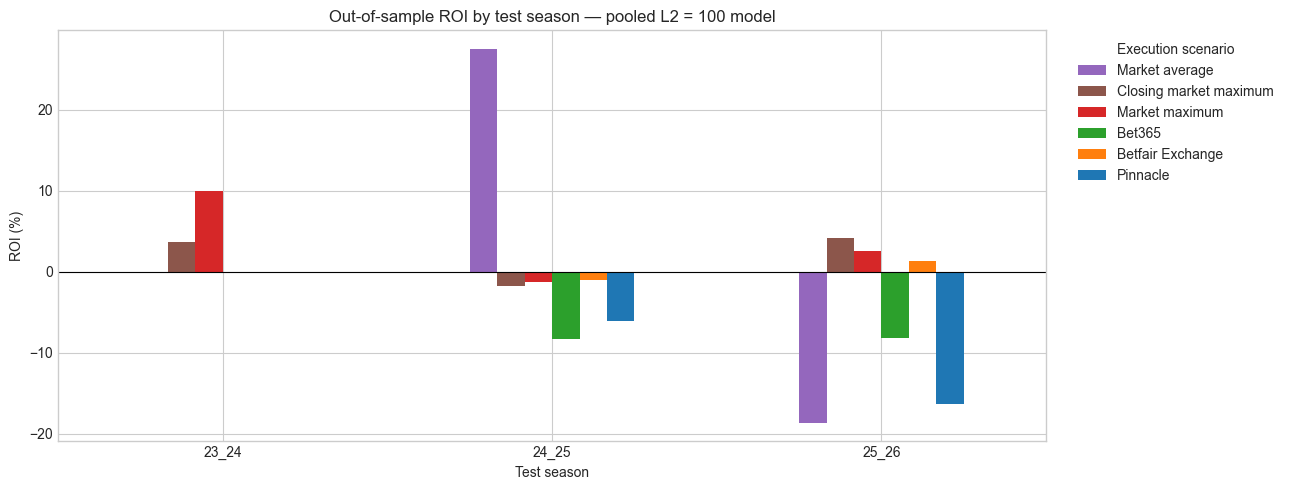

In [22]:
roi_matrix = performance_by_season.pivot(
    index="season", columns="execution_source", values="roi_pct"
)
roi_matrix = roi_matrix.rename(columns=SOURCE_LABELS)
ax = roi_matrix.plot(
    kind="bar",
    figsize=(13, 5),
    color=[SOURCE_COLORS[column] for column in roi_matrix.columns],
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set(
    title="Out-of-sample ROI by test season — pooled L2 = 100 model",
    xlabel="Test season",
    ylabel="ROI (%)",
)
ax.legend(title="Execution scenario", frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Approximate ROI confidence intervals, CLV, sample size, and subgroup consistency should be considered together. Positive ROI in a small cell is not persuasive when its interval includes zero or its CLV is negative.

## 5. Monthly ROI and strategy activity

Monthly ROI equals total realized profit divided by total one-unit stakes in that month. The activity plots show the corresponding number of selected matches. These panels diagnose temporal concentration; they are not independent monthly experiments.

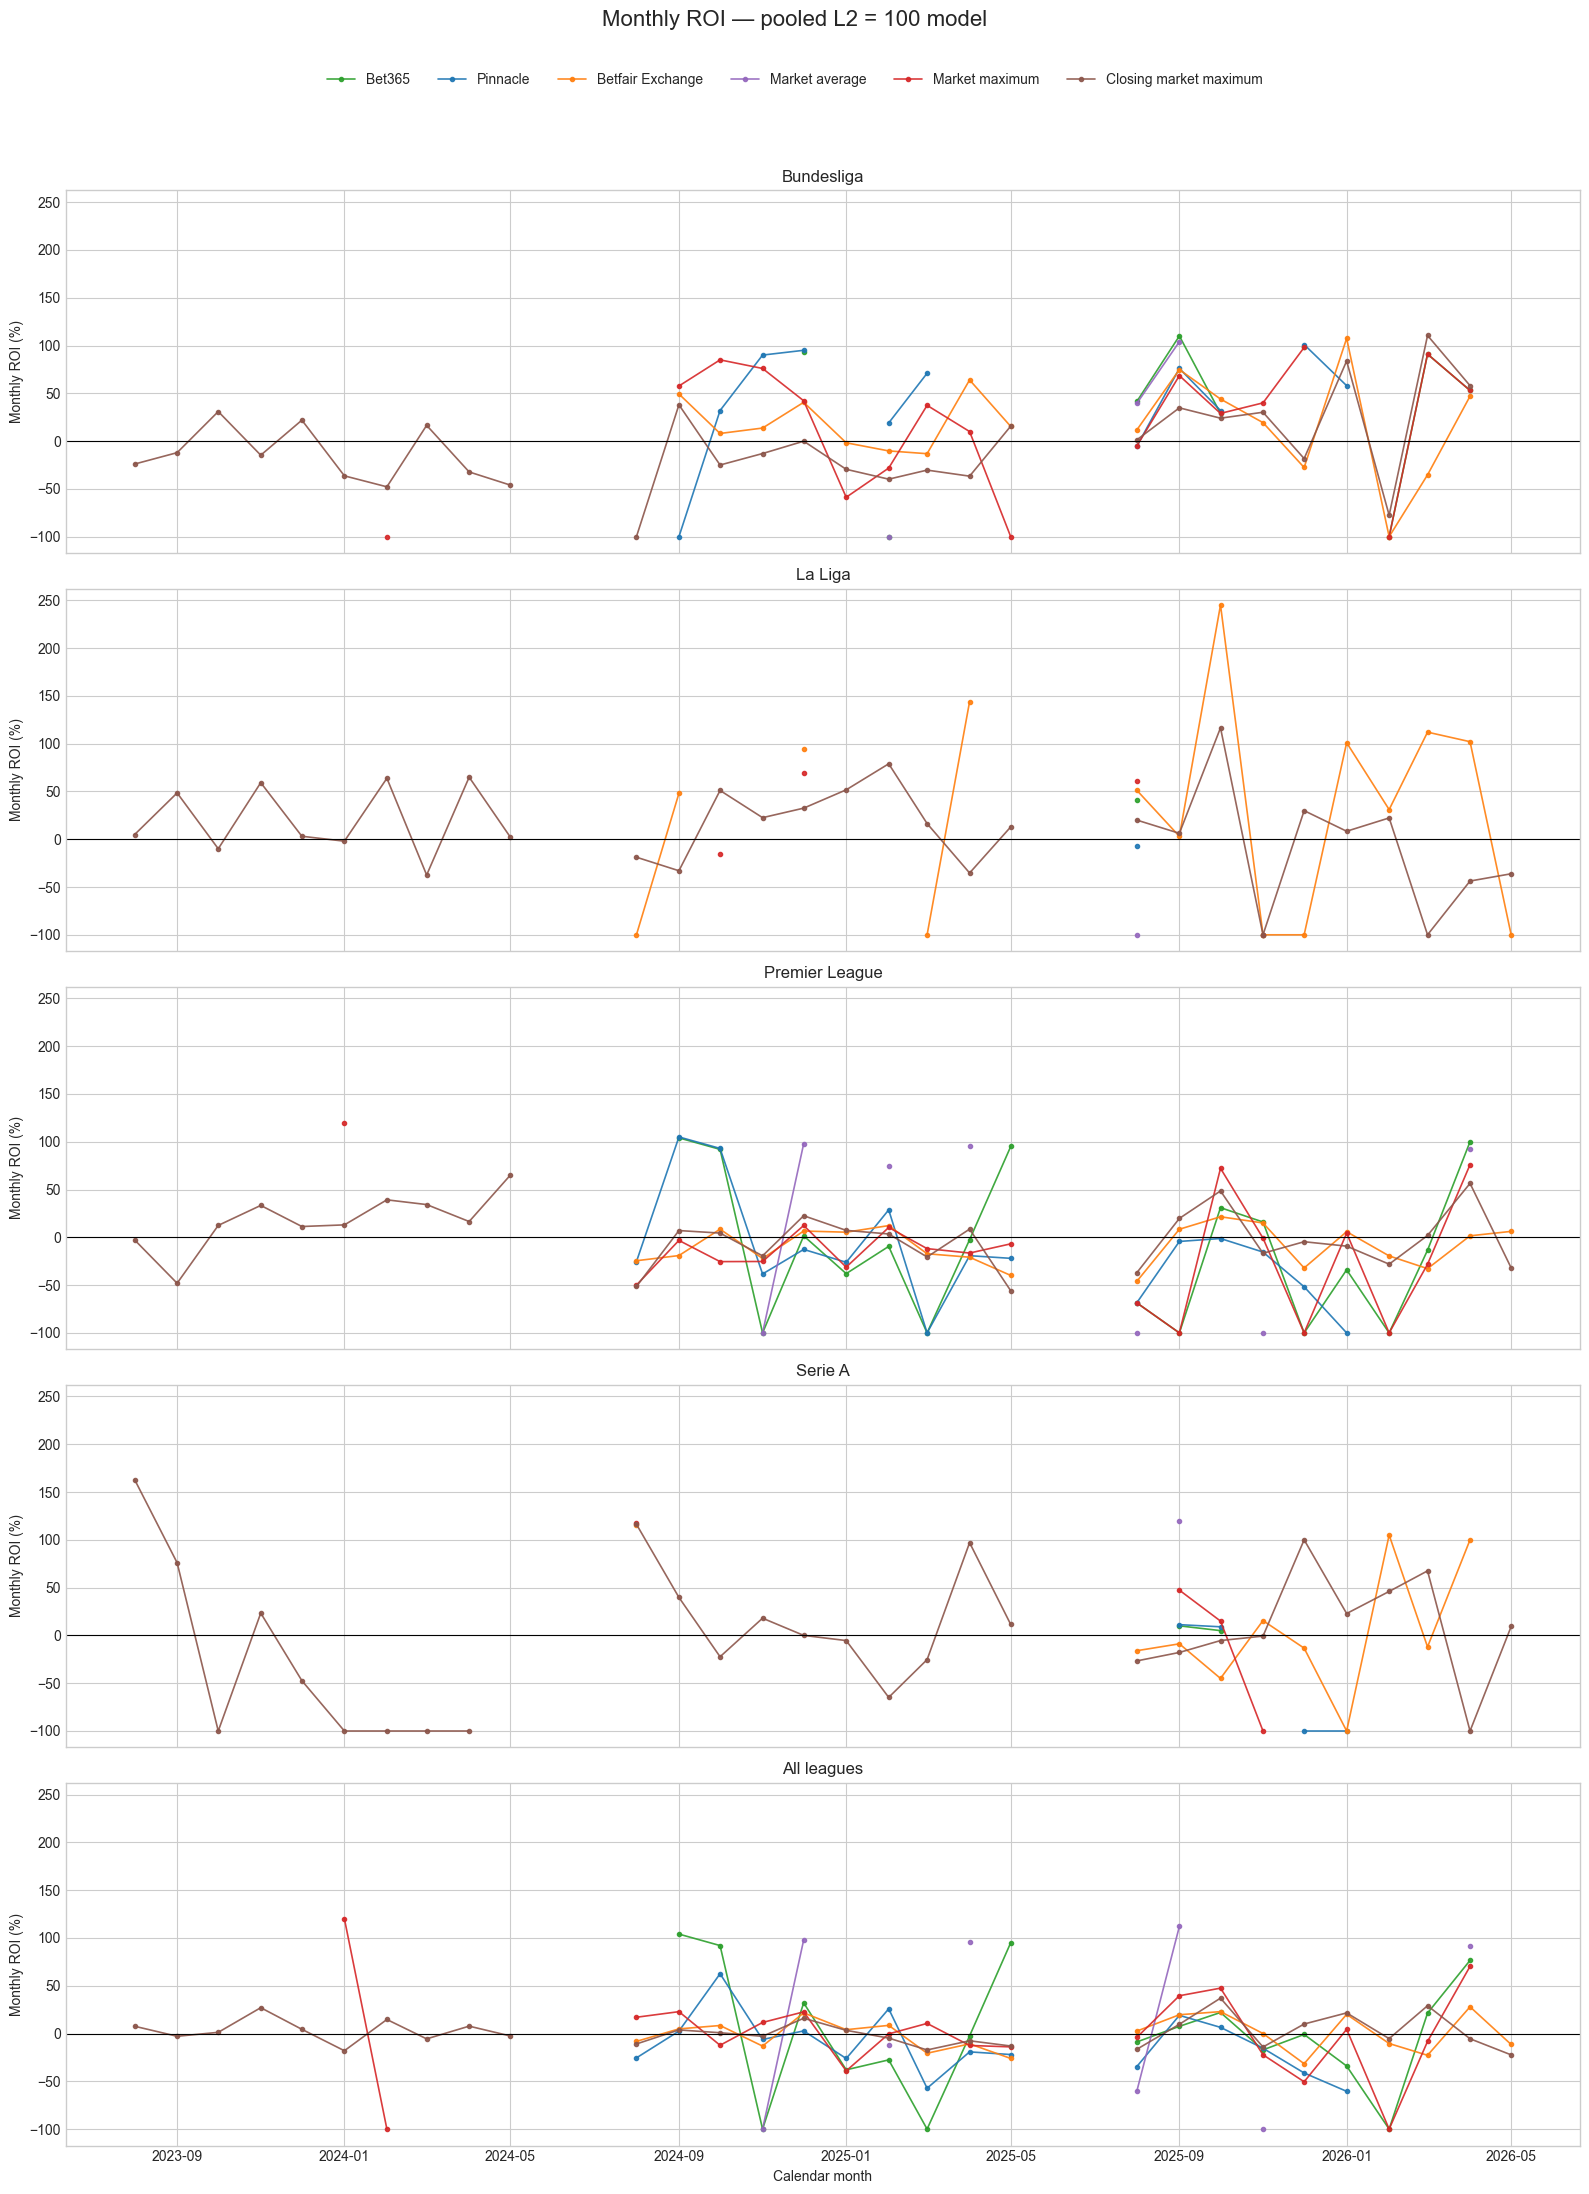

In [23]:
monthly_by_league = monthly_roi(
    execution_bets, ["league", "execution_source"]
)
monthly_all_leagues = monthly_roi(
    execution_bets, ["execution_source"]
)

plot_monthly_metric(
    monthly_by_league,
    monthly_all_leagues,
    value_column="roi_pct",
    title="Monthly ROI — pooled L2 = 100 model",
    y_label="Monthly ROI (%)",
    show_zero_line=True,
)
plt.show()

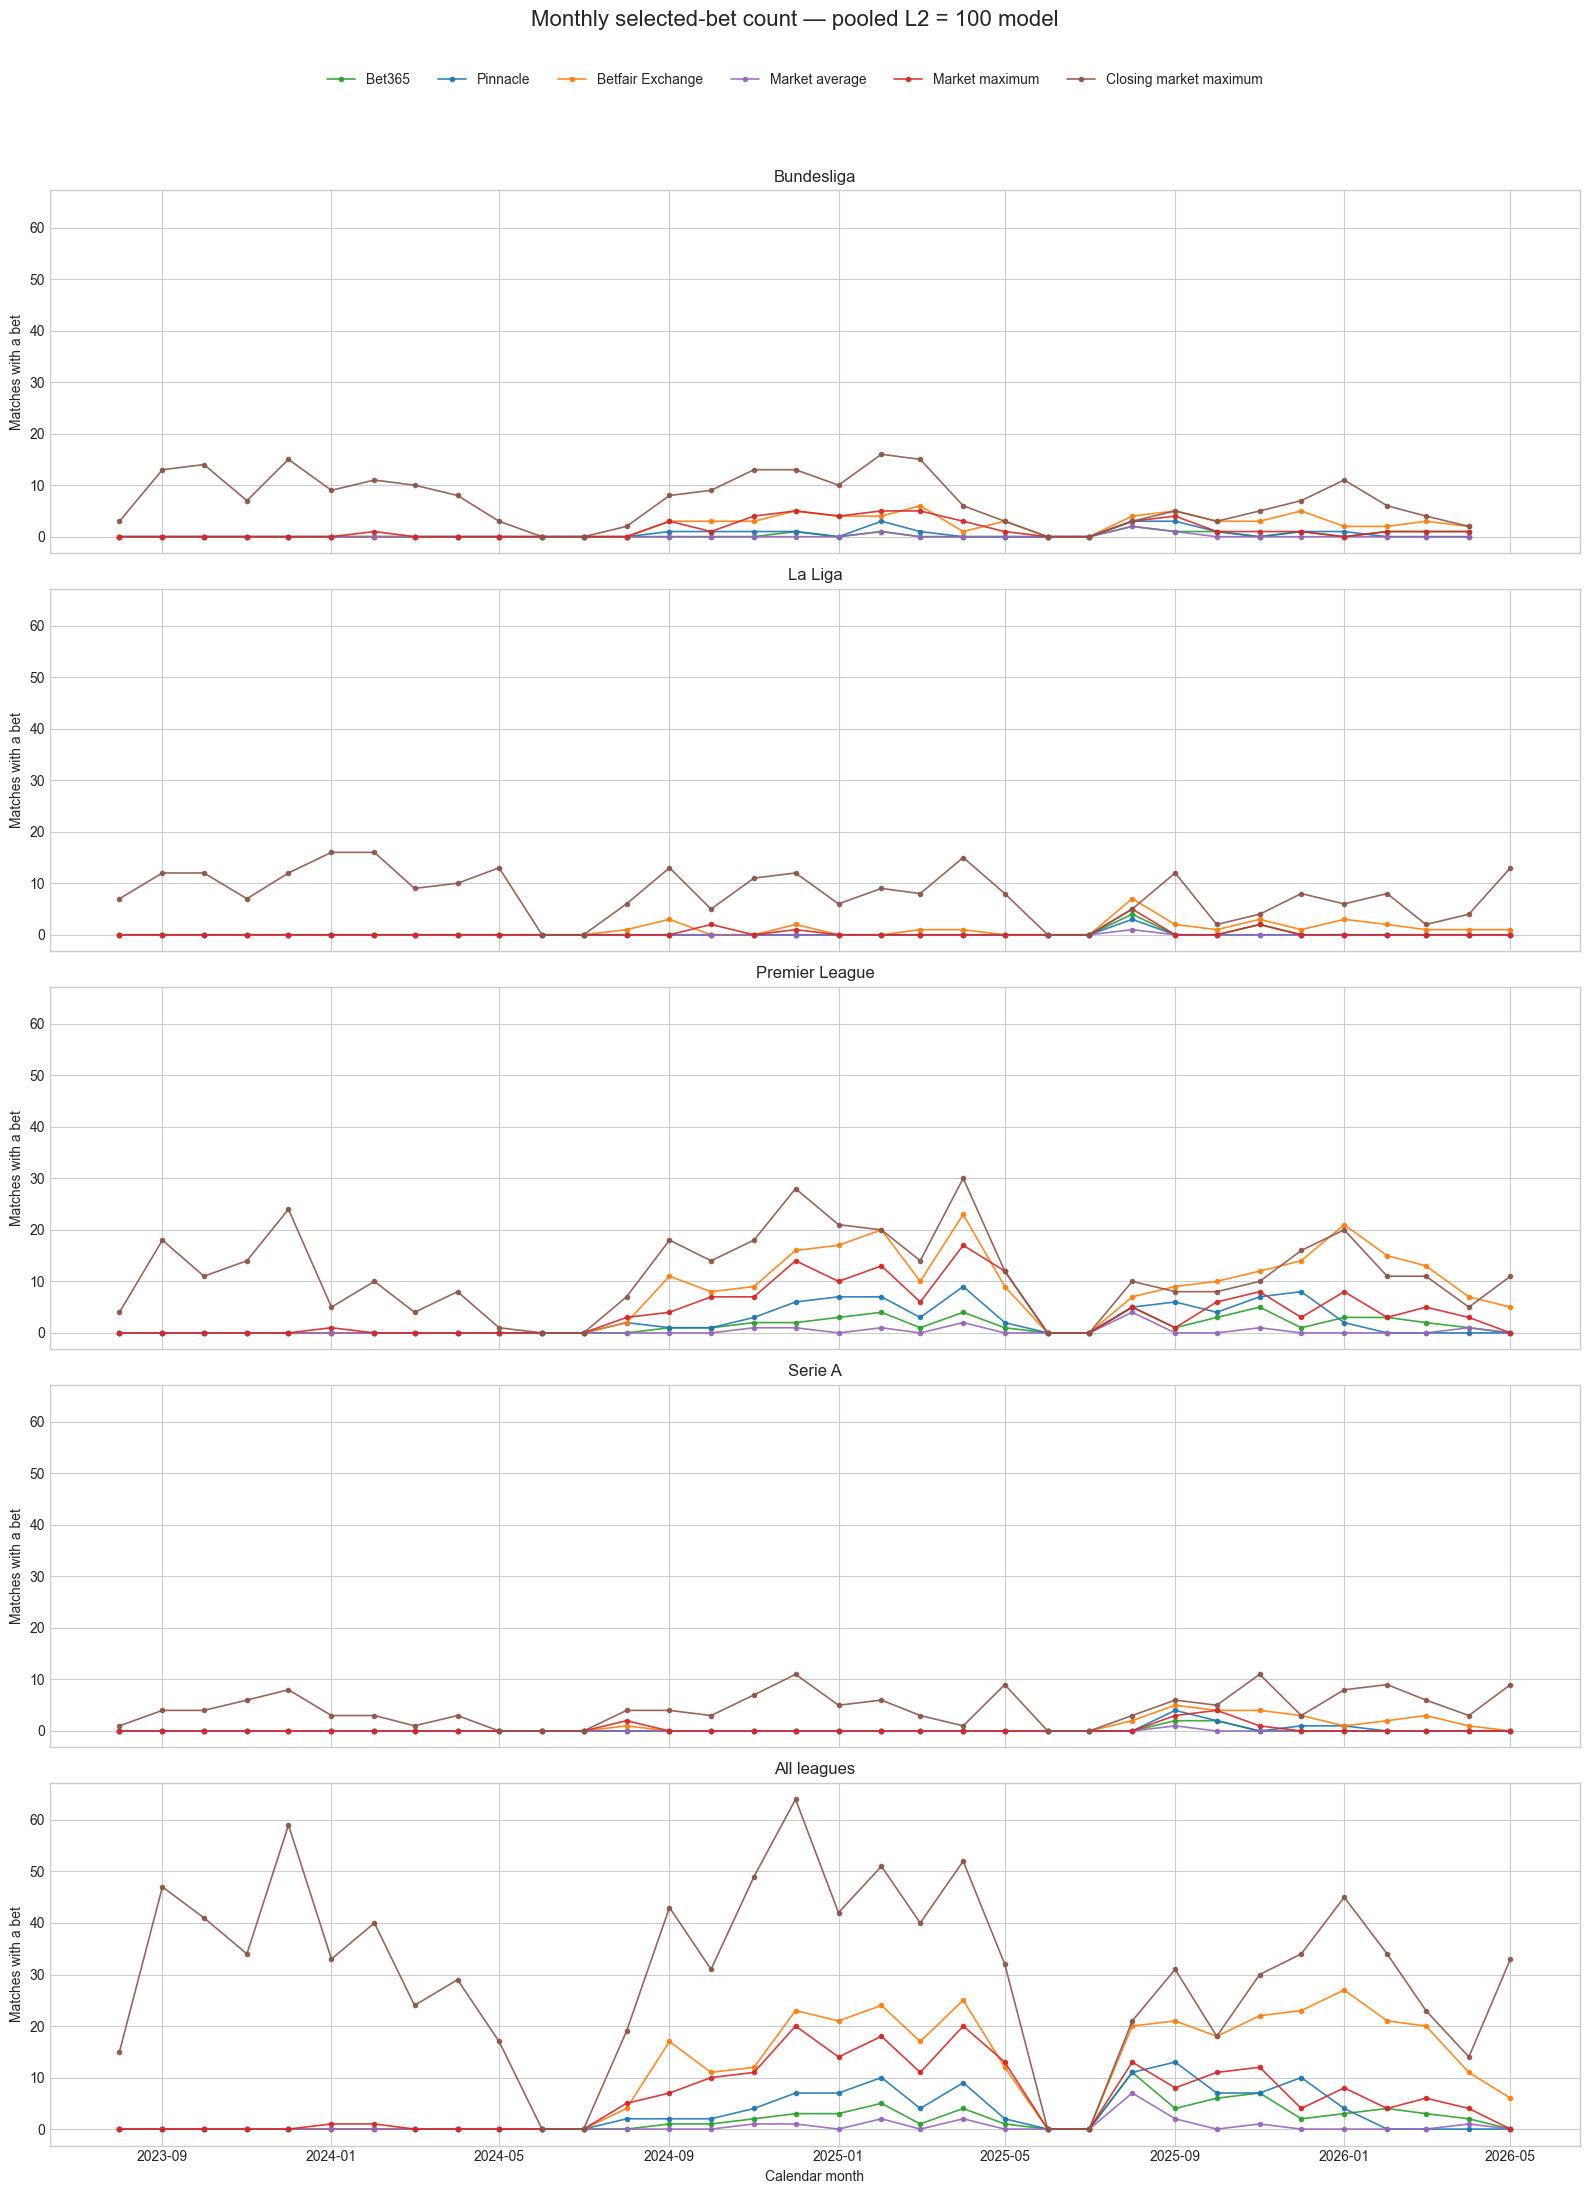

In [24]:
plot_monthly_metric(
    monthly_by_league,
    monthly_all_leagues,
    value_column="bets",
    title="Monthly selected-bet count — pooled L2 = 100 model",
    y_label="Matches with a bet",
    fill_missing=0,
)
plt.show()

## 6. Conclusion

Notebook 02 established that L2 = 100 is the strongest of the three fitted configurations: it improves Brier score, log loss, and calibration relative to L2 = 1 and L2 = 10. The improvement is modest, and the raw no-vig market remains slightly better overall as a probability forecaster.

The selected specification therefore does **not** establish a robust betting edge. Returns vary across execution sources, seasons, and leagues; approximate ROI intervals include zero; and mean CLV is generally negative. Stronger regularization is valuable because it suppresses unstable form effects and reduces overconfident selections, not because it turns the strategy into demonstrated alpha.

Important limitations remain: only three test seasons are available, L2 = 100 was selected after inspecting notebook 02, historical quote timestamps and availability cannot be verified, Betfair commission is excluded, and flat-stake ROI is not a bankroll return series. In particular, `MaxC>2.5` is an optimistic market-wide closing maximum rather than evidence that one account could consistently execute that price. A strong next test is a market-only fitted model versus this augmented model on the identical folds, followed by genuinely untouched future-season evaluation.